In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path.cwd().parent

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DATA_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)

<h2>Load all our analysis outputs</h2>

In [3]:
df = pd.read_csv(
    PROCESSED_DATA_DIR / "online_retail_cleaned.csv",
    parse_dates=["InvoiceDate"]
)

returns_df = pd.read_csv(
    PROCESSED_DATA_DIR / "online_retail_returns.csv",
    parse_dates=["InvoiceDate"]
)

product_df = pd.read_csv(
    REPORTS_DIR / "product_analysis.csv"
)

country_df = pd.read_csv(
    REPORTS_DIR / "country_analysis.csv"
)

rfm_df = pd.read_csv(
    REPORTS_DIR / "rfm_analysis.csv"
)

association_rules_df = pd.read_csv(
    REPORTS_DIR / "strong_association_rules.csv"
)

print("All analysis files loaded.")

All analysis files loaded.


<h2>Overall Business Metrics</h2>

In [4]:
total_revenue = df["TotalPrice"].sum()

total_units = df["Quantity"].sum()

total_orders = df["Invoice"].nunique()

total_customers = df["CustomerID"].nunique()

total_products = df["StockCode"].nunique()

total_countries = df["Country"].nunique()

average_order_value = (
    total_revenue / total_orders
)

average_units_per_order = (
    total_units / total_orders
)

return_units = (
    returns_df["Quantity"]
    .abs()
    .sum()
)

return_value = (
    returns_df["ReturnValue"]
    .sum()
)

return_rate = (
    return_units /
    total_units *
    100
)

return_value_rate = (
    return_value /
    total_revenue *
    100
)

<h2>Print the KPI Summary</h2>

In [5]:
print("=" * 70)
print("EXECUTIVE BUSINESS METRICS")
print("=" * 70)

print(f"Revenue:              £{total_revenue:,.2f}")
print(f"Units sold:           {total_units:,.0f}")
print(f"Orders:               {total_orders:,}")
print(f"Customers:            {total_customers:,}")
print(f"Products:             {total_products:,}")
print(f"Countries:            {total_countries:,}")
print(f"Average Order Value:  £{average_order_value:,.2f}")
print(f"Units / Order:        {average_units_per_order:.2f}")
print(f"Returned Units:       {return_units:,.0f}")
print(f"Return Rate:          {return_rate:.2f}%")
print(f"Return Value:         £{return_value:,.2f}")
print(f"Return Value Rate:    {return_value_rate:.2f}%")

print("=" * 70)

EXECUTIVE BUSINESS METRICS
Revenue:              £20,476,634.02
Units sold:           11,455,908
Orders:               41,942
Customers:            5,881
Products:             4,984
Countries:            43
Average Order Value:  £488.21
Units / Order:        273.14
Returned Units:       1,046,134
Return Rate:          9.13%
Return Value:         £1,462,424.18
Return Value Rate:    7.14%


<h2>Find Top Products</h2>

In [6]:
top_product = (
    product_df
    .sort_values(
        "Revenue",
        ascending=False
    )
    .iloc[0]
)

top_volume_product = (
    product_df
    .sort_values(
        "UnitsSold",
        ascending=False
    )
    .iloc[0]
)

print(
    "Top revenue product:",
    top_product["DescriptionClean"]
)

print(
    f"Revenue: £{top_product['Revenue']:,.2f}"
)

print()

print(
    "Top volume product:",
    top_volume_product["DescriptionClean"]
)

print(
    f"Units: {top_volume_product['UnitsSold']:,.0f}"
)

Top revenue product: MANUAL
Revenue: £339,599.81

Top volume product: WORLD WAR 2 GLIDERS ASSTD DESIGNS
Units: 106,250


<h2>Top Country</h2>

In [7]:
top_country = (
    country_df
    .sort_values(
        "Revenue",
        ascending=False
    )
    .iloc[0]
)

top_volume_country = (
    country_df
    .sort_values(
        "UnitsSold",
        ascending=False
    )
    .iloc[0]
)

print(
    f"Top country by revenue: "
    f"{top_country['Country']}"
)

print(
    f"Revenue: "
    f"£{top_country['Revenue']:,.2f}"
)

print()

print(
    f"Top country by volume: "
    f"{top_volume_country['Country']}"
)

print(
    f"Units: "
    f"{top_volume_country['UnitsSold']:,.0f}"
)

Top country by revenue: United Kingdom
Revenue: £17,410,569.69

Top country by volume: United Kingdom
Units: 9,437,245


<h2>Product Concentration</h2>

In [8]:
product_pareto = pd.read_csv(
    REPORTS_DIR /
    "product_pareto_analysis.csv"
)

products_80 = product_pareto[
    product_pareto["CumulativeRevenuePct"] <= 80
]

product_80_count = len(products_80)

product_80_pct = (
    product_80_count /
    len(product_pareto) *
    100
)

print(
    f"{product_80_count:,} products "
    f"({product_80_pct:.2f}%) "
    f"generate the first 80% of revenue."
)

1,150 products (19.87%) generate the first 80% of revenue.


<h2>Customer Segmentation Summary</h2>

In [9]:
rfm_df.head()

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score,RFM_Total,Segment,Cluster,ClusterLabel
0,"12,346.00",326,12,"77,556.46",2,5,5,255,12,Big Spenders,3,Cluster 3
1,"12,347.00",2,8,"4,921.53",5,4,5,545,14,Champions,3,Cluster 3
2,"12,348.00",75,5,"2,019.40",3,4,4,344,11,Loyal Customers,0,Cluster 0
3,"12,349.00",19,4,"4,428.69",5,3,5,535,13,Potential Loyalists,2,Cluster 2
4,"12,350.00",310,1,334.40,2,1,2,212,5,Others,1,Cluster 1


In [10]:
rfm_df.columns.tolist()

['CustomerID',
 'Recency',
 'Frequency',
 'Monetary',
 'R_Score',
 'F_Score',
 'M_Score',
 'RFM_Score',
 'RFM_Total',
 'Segment',
 'Cluster',
 'ClusterLabel']

In [11]:
rfm_segments = (
    rfm_df["Segment"]
    .value_counts()
)

rfm_segments

Segment
Others                 1378
Champions              1297
Lost Customers          880
At Risk                 727
Potential Loyalists     714
Loyal Customers         701
Big Spenders            129
New Customers            55
Name: count, dtype: int64

<h2>Customer Segment Chart</h2>

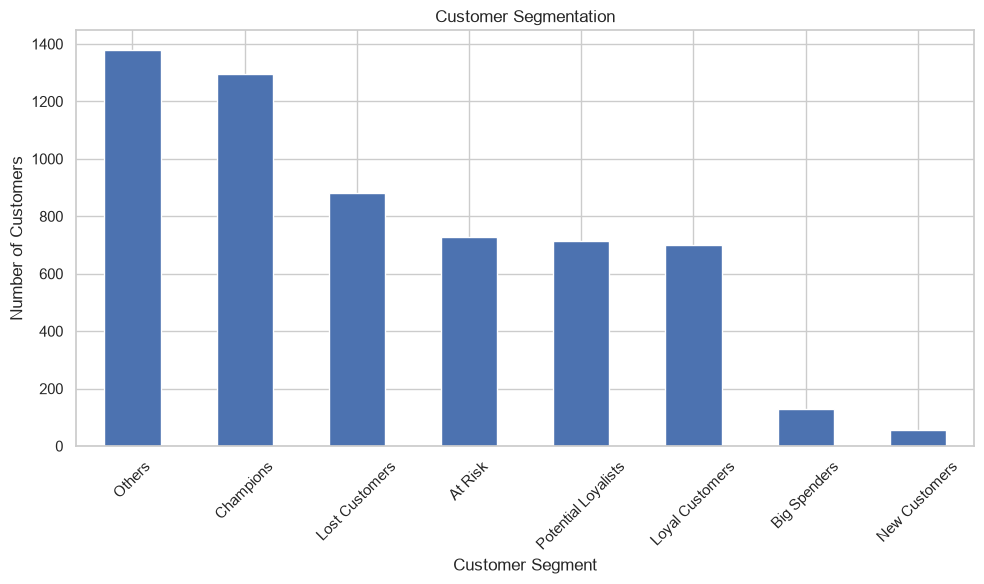

In [12]:
plt.figure(figsize=(10, 6))

rfm_segments.plot(
    kind="bar"
)

plt.title(
    "Customer Segmentation"
)

plt.xlabel("Customer Segment")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "customer_segments.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Monthly Revenue</h2>

In [13]:
monthly_revenue = (
    df
    .set_index("InvoiceDate")
    .resample("ME")["TotalPrice"]
    .sum()
    .reset_index()
)

monthly_revenue.head()

,InvoiceDate,TotalPrice
0,2009-12-31,"822,483.95"
1,2010-01-31,"651,155.11"
2,2010-02-28,"551,878.30"
3,2010-03-31,"830,915.26"
4,2010-04-30,"678,875.25"


<h2>Revenue Trend Chart</h2>

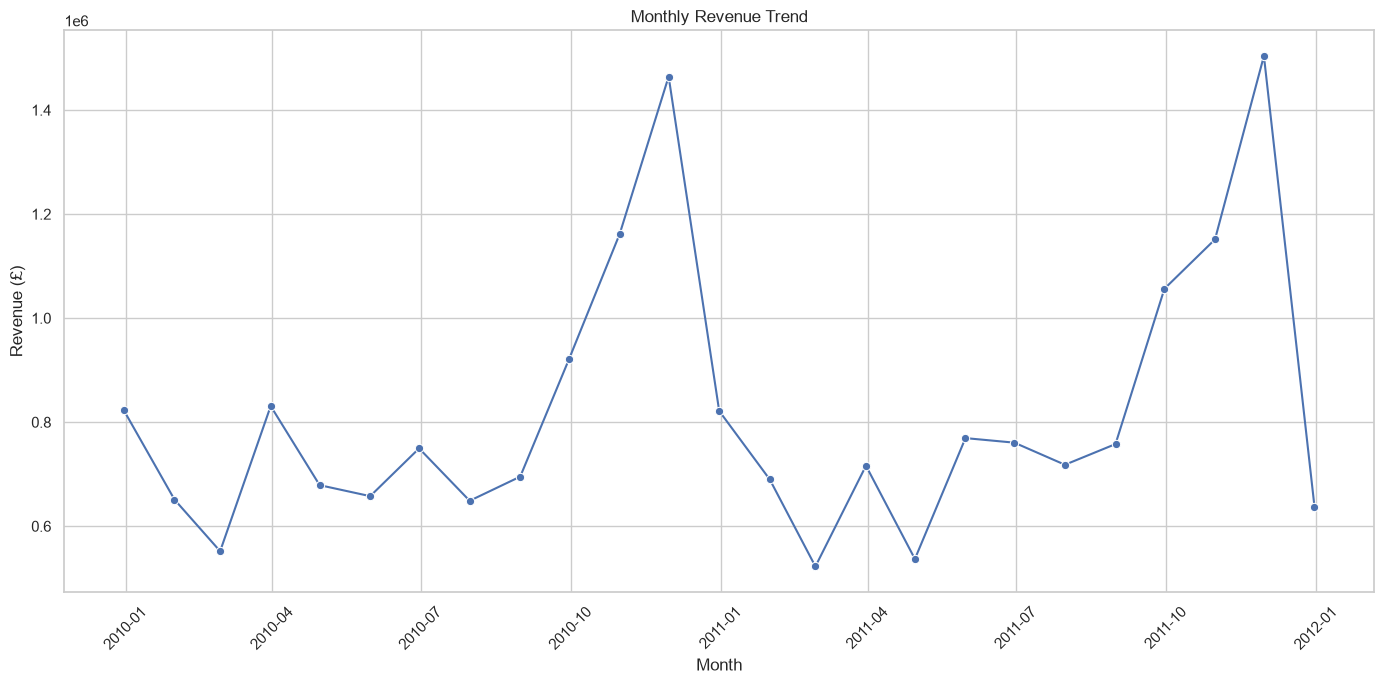

In [14]:
plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_revenue,
    x="InvoiceDate",
    y="TotalPrice",
    marker="o"
)

plt.title(
    "Monthly Revenue Trend"
)

plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "monthly_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Monthly Orders</h2>

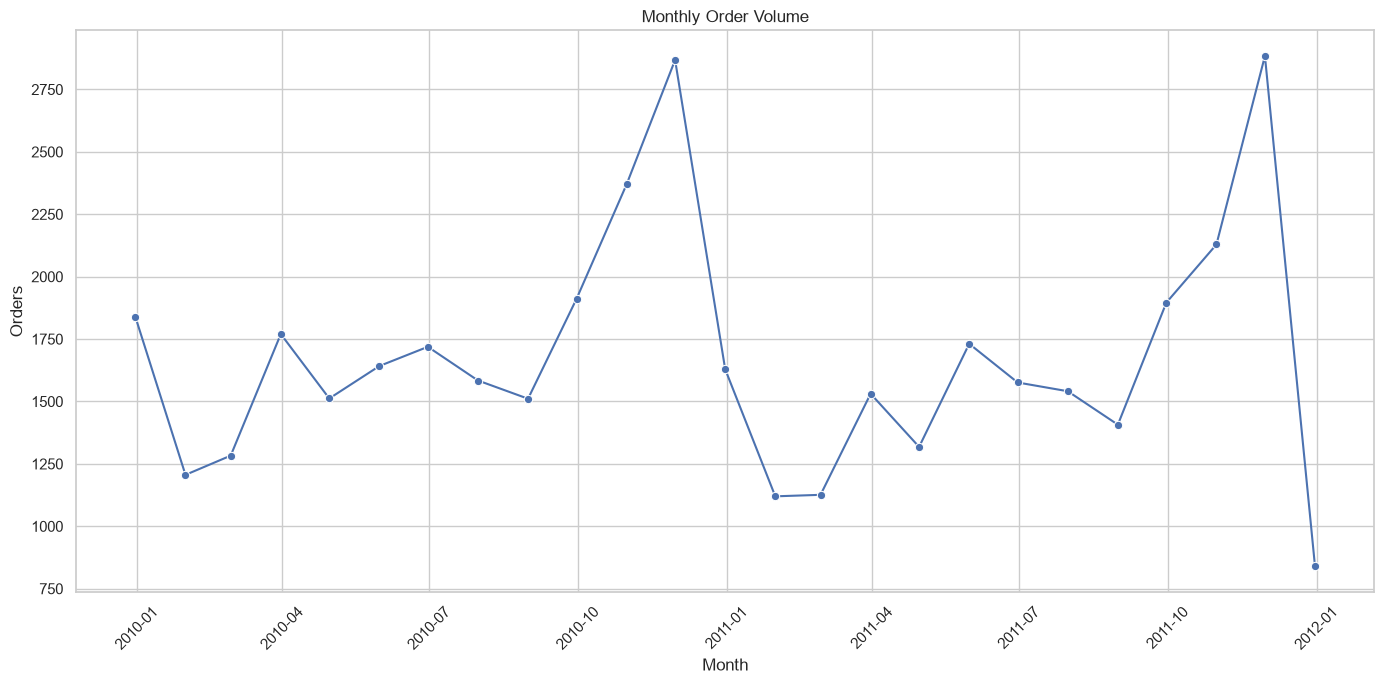

In [15]:
monthly_orders = (
    df
    .set_index("InvoiceDate")
    .resample("ME")["Invoice"]
    .nunique()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_orders,
    x="InvoiceDate",
    y="Invoice",
    marker="o"
)

plt.title(
    "Monthly Order Volume"
)

plt.xlabel("Month")
plt.ylabel("Orders")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "monthly_orders.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Returns Trend</h2>

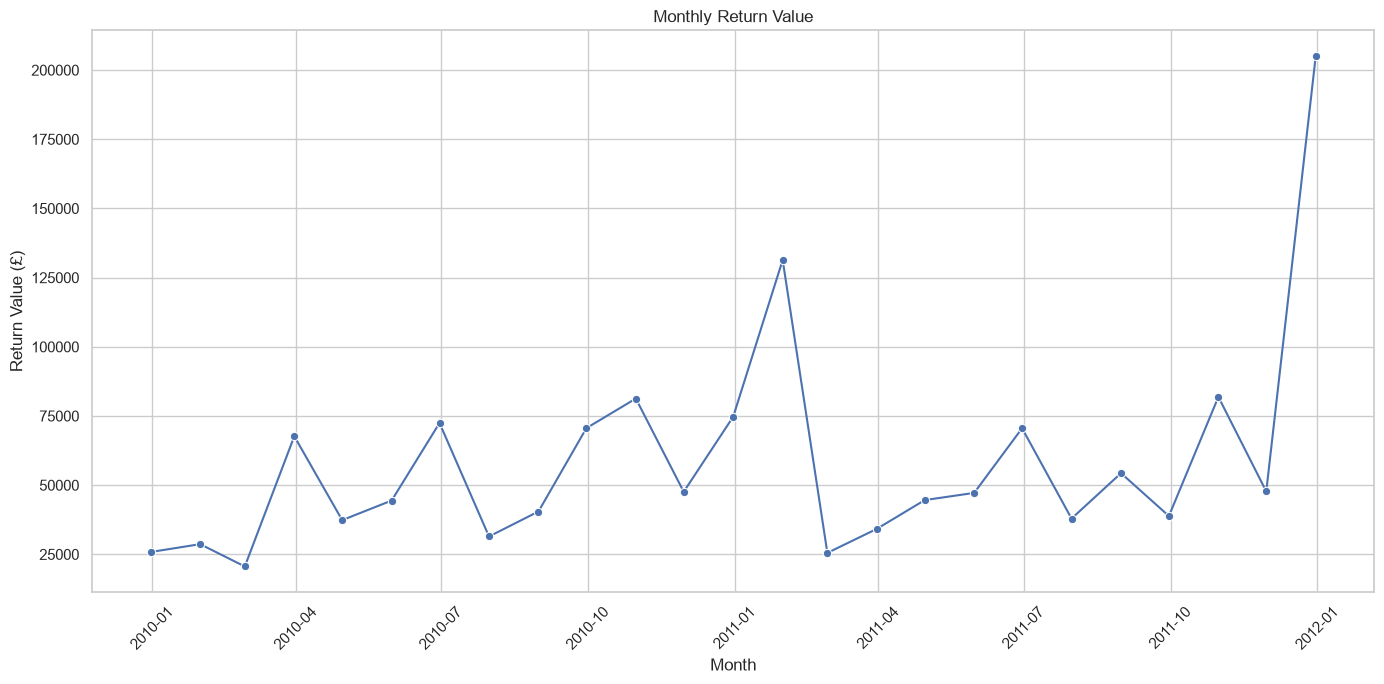

In [16]:
monthly_returns = (
    returns_df
    .set_index("InvoiceDate")
    .resample("ME")["ReturnValue"]
    .sum()
    .reset_index()
)

plt.figure(figsize=(14, 7))

sns.lineplot(
    data=monthly_returns,
    x="InvoiceDate",
    y="ReturnValue",
    marker="o"
)

plt.title(
    "Monthly Return Value"
)

plt.xlabel("Month")
plt.ylabel("Return Value (£)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "monthly_returns.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Top Countries Chart</h2>

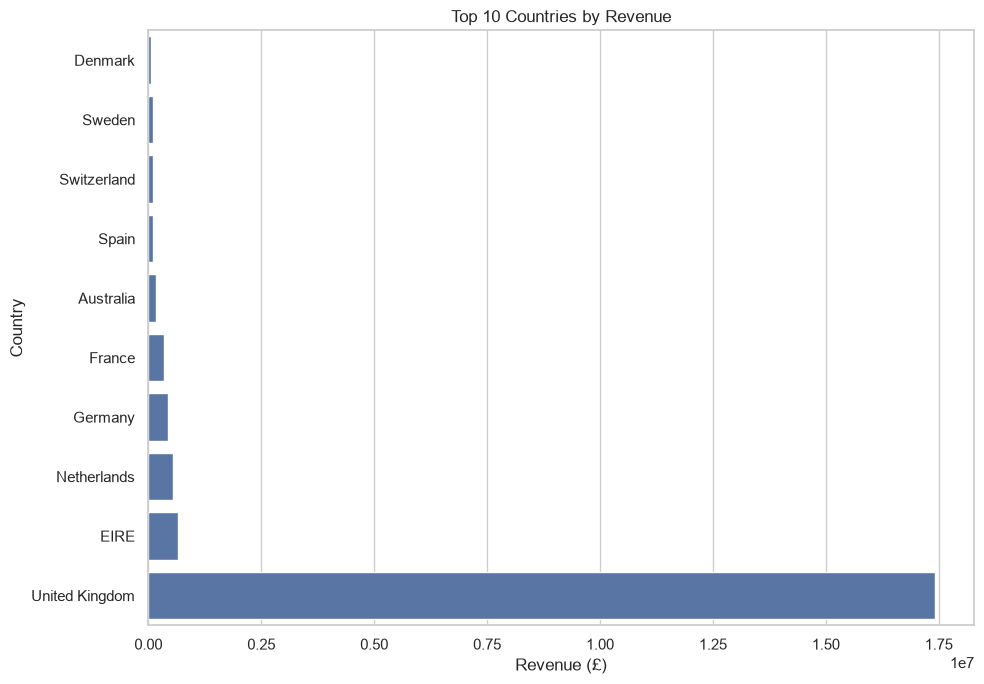

In [17]:
top_countries = (
    country_df
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(10, 7))

sns.barplot(
    data=top_countries,
    x="Revenue",
    y="Country"
)

plt.title(
    "Top 10 Countries by Revenue"
)

plt.xlabel("Revenue (£)")
plt.ylabel("Country")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "top_countries_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Top Products Chart</h2>

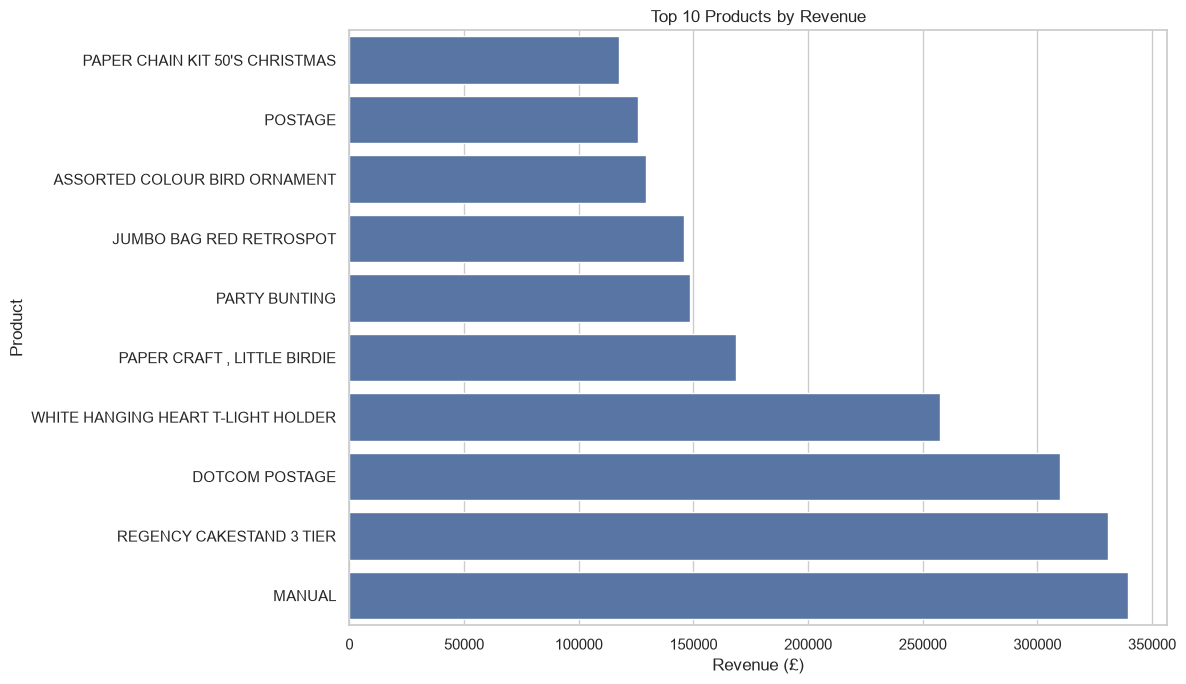

In [18]:
top_products = (
    product_df
    .sort_values(
        "Revenue",
        ascending=False
    )
    .head(10)
    .sort_values("Revenue")
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products,
    x="Revenue",
    y="DescriptionClean"
)

plt.title(
    "Top 10 Products by Revenue"
)

plt.xlabel("Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "top_products_revenue.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Return Rate Chart</h2>

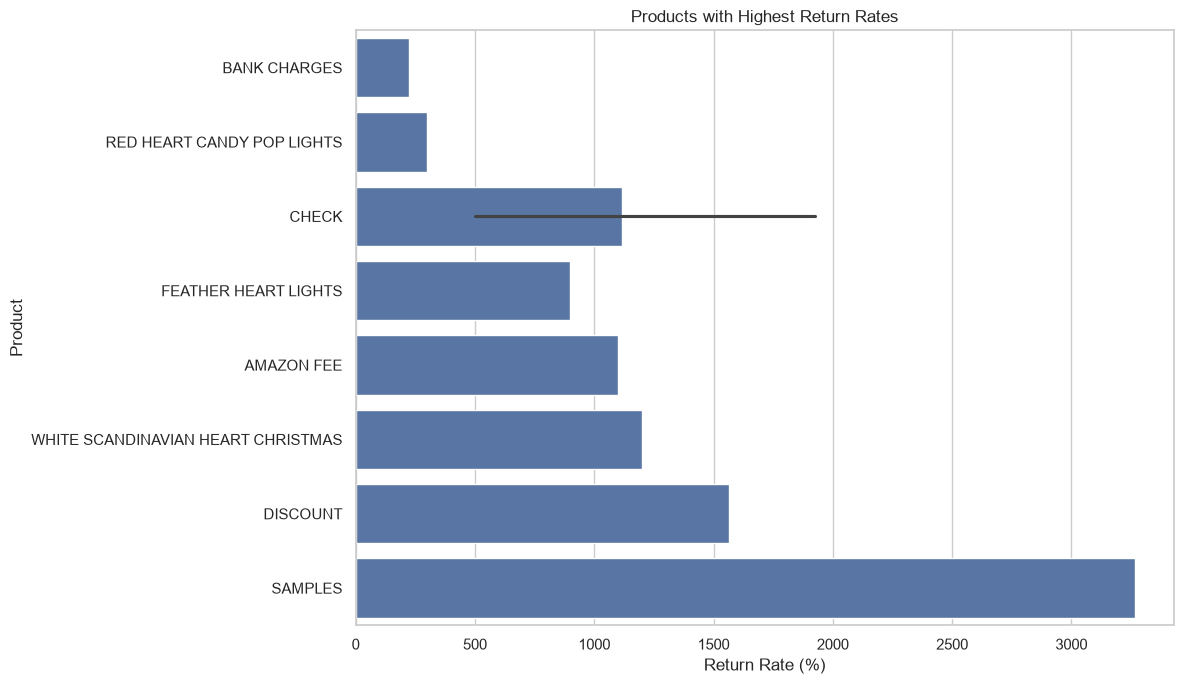

In [19]:
return_products = (
    product_df
    .sort_values(
        "ReturnRate",
        ascending=False
    )
    .head(10)
    .sort_values("ReturnRate")
)

plt.figure(figsize=(12, 7))

sns.barplot(
    data=return_products,
    x="ReturnRate",
    y="DescriptionClean"
)

plt.title(
    "Products with Highest Return Rates"
)

plt.xlabel("Return Rate (%)")
plt.ylabel("Product")

plt.tight_layout()

plt.savefig(
    FIGURES_DIR /
    "highest_return_products.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h2>Save KPI Data</h2>

In [20]:
kpis = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Units",
        "Total Orders",
        "Total Customers",
        "Total Products",
        "Total Countries",
        "Average Order Value",
        "Average Units per Order",
        "Returned Units",
        "Return Rate",
        "Return Value",
        "Return Value Rate"
    ],
    "Value": [
        total_revenue,
        total_units,
        total_orders,
        total_customers,
        total_products,
        total_countries,
        average_order_value,
        average_units_per_order,
        return_units,
        return_rate,
        return_value,
        return_value_rate
    ]
})

kpis.to_csv(
    REPORTS_DIR / "executive_kpis.csv",
    index=False
)

kpis

,Metric,Value
0,Total Revenue,"20,476,634.02"
1,Total Units,"11,455,908.00"
2,Total Orders,"41,942.00"
3,Total Customers,"5,881.00"
4,Total Products,"4,984.00"
5,Total Countries,43.00
6,Average Order Value,488.21
7,Average Units per Order,273.14
8,Returned Units,"1,046,134.00"
9,Return Rate,9.13
